In [8]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
data = {
    "Category": [
        "Technology",
        "Sports",
        "Business",
        "Entertainment",
        "Technology",
        "Sports",
        "Business",
        "Entertainment",
        "Technology",
        "Sports",
        "Business",
        "Entertainment",
        "Technology",
        "Sports",
        "Business",
        "Entertainment"
    ],

    "Article": [
        "Apple launches its latest AI-powered smartphone with advanced camera features.",
        "India won the cricket match by five wickets after an exciting chase.",
        "Stock markets gained as technology companies reported strong quarterly profits.",
        "The new superhero movie broke all box office records on its opening weekend.",
        "Researchers developed a new machine learning model for healthcare prediction.",
        "The football team secured the championship after a thrilling final match.",
        "The company announced a major investment in renewable energy projects.",
        "A famous singer released a new album that topped global music charts.",
        "Cybersecurity experts warned users about a new ransomware attack.",
        "The tennis player won her third Grand Slam title this year.",
        "Banks reduced interest rates to encourage business investments.",
        "The actor received the award for best performance in the film festival.",
        "Scientists introduced an AI robot capable of assisting elderly people.",
        "The basketball league season begins next month with 20 participating teams.",
        "The startup raised millions of dollars from international investors.",
        "The television series became the most streamed show of the year."
    ]
}

In [10]:
df = pd.DataFrame(data)
print(df.head())

        Category                                            Article
0     Technology  Apple launches its latest AI-powered smartphon...
1         Sports  India won the cricket match by five wickets af...
2       Business  Stock markets gained as technology companies r...
3  Entertainment  The new superhero movie broke all box office r...
4     Technology  Researchers developed a new machine learning m...


In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','',text)

    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [13]:
df["Clean_Article"] = df["Article"].apply(clean_text)
print(df[["Article","Clean_Article"]].head())

                                             Article  \
0  Apple launches its latest AI-powered smartphon...   
1  India won the cricket match by five wickets af...   
2  Stock markets gained as technology companies r...   
3  The new superhero movie broke all box office r...   
4  Researchers developed a new machine learning m...   

                                       Clean_Article  
0  apple launch latest aipowered smartphone advan...  
1     india cricket match five wicket exciting chase  
2  stock market gained technology company reporte...  
3  new superhero movie broke box office record op...  
4  researcher developed new machine learning mode...  


In [14]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Clean_Article"])
y = df["Category"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.25,
    random_state=42
)

In [16]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [17]:
y_pred = model.predict(X_test)

print("Predicted Categories:")
print(y_pred)

Predicted Categories:
['Entertainment' 'Entertainment' 'Entertainment' 'Entertainment']


In [18]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.0

Classification Report
               precision    recall  f1-score   support

     Business       0.00      0.00      0.00       1.0
Entertainment       0.00      0.00      0.00       0.0
       Sports       0.00      0.00      0.00       2.0
   Technology       0.00      0.00      0.00       1.0

     accuracy                           0.00       4.0
    macro avg       0.00      0.00      0.00       4.0
 weighted avg       0.00      0.00      0.00       4.0


Confusion Matrix
[[0 1 0 0]
 [0 0 0 0]
 [0 2 0 0]
 [0 1 0 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [19]:
new_article = [
    "Google introduced a new artificial intelligence model for smartphones."
]

new_article = [clean_text(text) for text in new_article]
new_vector = vectorizer.transform(new_article)
prediction = model.predict(new_vector)
print("Predicted Category :", prediction[0])

Predicted Category : Technology


In [22]:
from wordcloud import WordCloud

all_words = " ".join(df["Clean_Article"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)


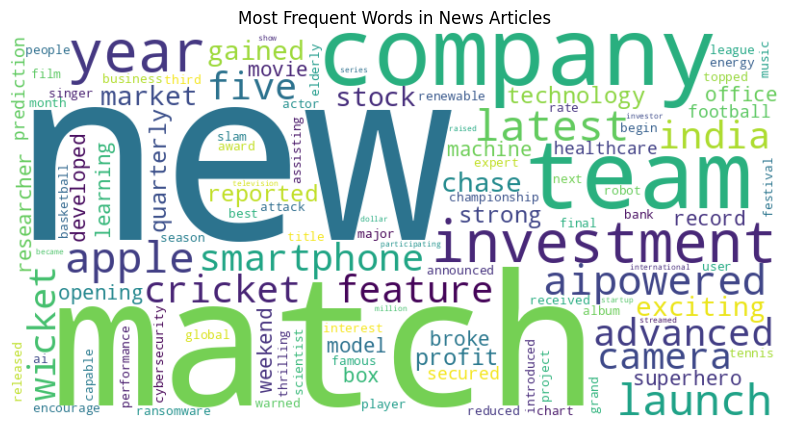

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in News Articles")
plt.show()